In [1]:
import pandas as pd
import numpy as np

np.random.seed(42)

n = 2500

df = pd.DataFrame({
    "CustomerID": np.arange(10000, 10000+n),
    "Age": np.random.randint(15, 80, n),  # includes invalid ages
    "Email": np.random.choice(
        ["user@gmail.com", "invalid_email", None, "test@company.com"], n
    ),
    "PhoneNumber": np.random.choice(
        ["1234567890", "invalid_phone", None], n
    ),
    "TransactionAmount": np.random.uniform(-500, 10000, n),  # negative = bad
    "AccountBalance": np.random.uniform(-1000, 50000, n),
    "TransactionType": np.random.choice(["Debit","Credit"], n),
    "Country": np.random.choice(["USA","UK","India",None], n),
    "City": np.random.choice(["NY","London","Mumbai","Dallas"], n),
    "SignupDate": np.random.choice(pd.date_range("2020-01-01","2023-12-31"), n),
    "TransactionDate": np.random.choice(pd.date_range("2023-01-01","2024-12-31"), n),
    "Device": np.random.choice(["Mobile","Desktop","Tablet"], n),
    "Browser": np.random.choice(["Chrome","Safari","Edge","Firefox"], n),
    "IsActive": np.random.choice([0,1], n),
    "LoginAttempts": np.random.randint(0, 10, n),
    "FraudFlag": np.random.choice([0,1], n),
    "Income": np.random.uniform(20000, 150000, n),
    "CreditScore": np.random.randint(300, 900, n),
    "LoanAmount": np.random.uniform(0, 50000, n),
    "LoanStatus": np.random.choice(["Approved","Rejected","Pending"], n)
})

# Save raw data
df.to_csv("raw_data_quality_data.csv", index=False)

df.head()

,CustomerID,Age,Email,PhoneNumber,TransactionAmount,AccountBalance,TransactionType,Country,City,SignupDate,TransactionDate,Device,Browser,IsActive,LoginAttempts,FraudFlag,Income,CreditScore,LoanAmount,LoanStatus
0,10000,66,user@gmail.com,invalid_phone,4617.766183,20175.901591,Credit,USA,NY,2023-11-02,2024-02-15,Mobile,Edge,1,5,0,45569.232345,705,48323.933645,Approved
1,10001,29,invalid_email,None,9426.402321,30369.655656,Debit,India,London,2022-03-28,2024-11-21,Mobile,Edge,0,4,1,43538.321315,795,4219.524802,Rejected
2,10002,75,test@company.com,1234567890,100.985282,23540.595725,Debit,USA,Mumbai,2020-02-29,2024-06-08,Desktop,Safari,1,5,1,91867.956210,566,40938.205128,Approved
3,10003,35,invalid_email,invalid_phone,9275.485507,22434.615595,Debit,UK,Mumbai,2021-04-11,2024-03-22,Mobile,Chrome,0,0,0,137611.325872,893,17077.893823,Rejected
4,10004,38,test@company.com,None,30.327620,17487.996297,Credit,India,Dallas,2021-09-19,2023-10-27,Desktop,Safari,0,3,0,122530.070583,363,42473.401299,Rejected


In [2]:
df.shape

(2500, 20)

In [3]:
!ls

raw_data_quality_data.csv  sample_data


In [4]:
import re

# Create a dictionary to store validation results
validation_results = {}

# --- 1. Missing Values Check ---
missing = df.isnull().sum()
validation_results['MissingValues'] = missing

# --- 2. Age Validation (should be between 18–65) ---
invalid_age = df[(df['Age'] < 18) | (df['Age'] > 65)]
validation_results['InvalidAgeCount'] = len(invalid_age)

# --- 3. Email Validation ---
def is_valid_email(email):
    if pd.isnull(email):
        return False
    pattern = r'^[\w\.-]+@[\w\.-]+\.\w+$'
    return re.match(pattern, email) is not None

df['ValidEmail'] = df['Email'].apply(is_valid_email)
validation_results['InvalidEmailCount'] = len(df[df['ValidEmail'] == False])

# --- 4. Phone Validation (10 digits only) ---
df['ValidPhone'] = df['PhoneNumber'].str.match(r'^\d{10}$', na=False)
validation_results['InvalidPhoneCount'] = len(df[df['ValidPhone'] == False])

# --- 5. Transaction Amount Validation (should be > 0) ---
invalid_txn = df[df['TransactionAmount'] <= 0]
validation_results['InvalidTransactionCount'] = len(invalid_txn)

# --- 6. Credit Score Validation (300–850) ---
invalid_credit = df[(df['CreditScore'] < 300) | (df['CreditScore'] > 850)]
validation_results['InvalidCreditScoreCount'] = len(invalid_credit)

# --- 7. Date Validation (TransactionDate >= SignupDate) ---
invalid_dates = df[df['TransactionDate'] < df['SignupDate']]
validation_results['InvalidDateLogicCount'] = len(invalid_dates)

# --- Print Results ---
for key, value in validation_results.items():
    print(f"{key}:\n{value}\n")

MissingValues:
CustomerID             0
Age                    0
Email                636
PhoneNumber          828
TransactionAmount      0
AccountBalance         0
TransactionType        0
Country              602
City                   0
SignupDate             0
TransactionDate        0
Device                 0
Browser                0
IsActive               0
LoginAttempts          0
FraudFlag              0
Income                 0
CreditScore            0
LoanAmount             0
LoanStatus             0
dtype: int64

InvalidAgeCount:
651

InvalidEmailCount:
1239

InvalidPhoneCount:
1688

InvalidTransactionCount:
122

InvalidCreditScoreCount:
218

InvalidDateLogicCount:
142



In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Create Data Quality Flags (1 = bad, 0 = good) ---

df['InvalidAgeFlag'] = ((df['Age'] < 18) | (df['Age'] > 65)).astype(int)
df['InvalidTxnFlag'] = (df['TransactionAmount'] <= 0).astype(int)
df['InvalidCreditFlag'] = ((df['CreditScore'] < 300) | (df['CreditScore'] > 850)).astype(int)
df['InvalidDateFlag'] = (df['TransactionDate'] < df['SignupDate']).astype(int)
df['InvalidEmailFlag'] = (~df['ValidEmail']).astype(int)
df['InvalidPhoneFlag'] = (~df['ValidPhone']).astype(int)

# --- Data Quality Score (higher = worse data) ---
df['DataQualityScore'] = (
    df[['InvalidAgeFlag','InvalidTxnFlag','InvalidCreditFlag',
        'InvalidDateFlag','InvalidEmailFlag','InvalidPhoneFlag']].sum(axis=1)
)

df.head()

,CustomerID,Age,Email,PhoneNumber,TransactionAmount,AccountBalance,TransactionType,Country,City,SignupDate,...,LoanStatus,ValidEmail,ValidPhone,InvalidAgeFlag,InvalidTxnFlag,InvalidCreditFlag,InvalidDateFlag,InvalidEmailFlag,InvalidPhoneFlag,DataQualityScore
0,10000,66,user@gmail.com,invalid_phone,4617.766183,20175.901591,Credit,USA,NY,2023-11-02,...,Approved,True,False,1,0,0,0,0,1,2
1,10001,29,invalid_email,None,9426.402321,30369.655656,Debit,India,London,2022-03-28,...,Rejected,False,False,0,0,0,0,1,1,2
2,10002,75,test@company.com,1234567890,100.985282,23540.595725,Debit,USA,Mumbai,2020-02-29,...,Approved,True,True,1,0,0,0,0,0,1
3,10003,35,invalid_email,invalid_phone,9275.485507,22434.615595,Debit,UK,Mumbai,2021-04-11,...,Rejected,False,False,0,0,1,0,1,1,3
4,10004,38,test@company.com,None,30.327620,17487.996297,Credit,India,Dallas,2021-09-19,...,Rejected,True,False,0,0,0,0,0,1,1


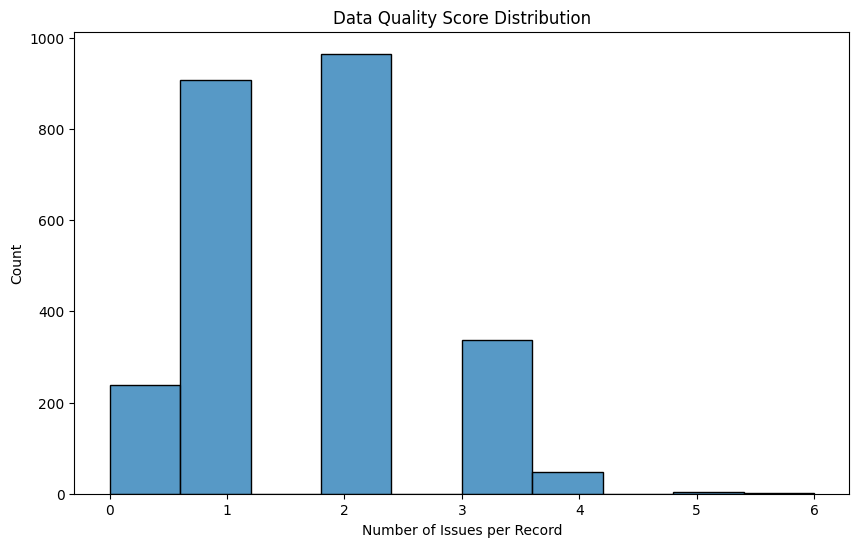

In [6]:
plt.figure(figsize=(10,6))
sns.histplot(df['DataQualityScore'], bins=10)

plt.title("Data Quality Score Distribution")
plt.xlabel("Number of Issues per Record")
plt.show()

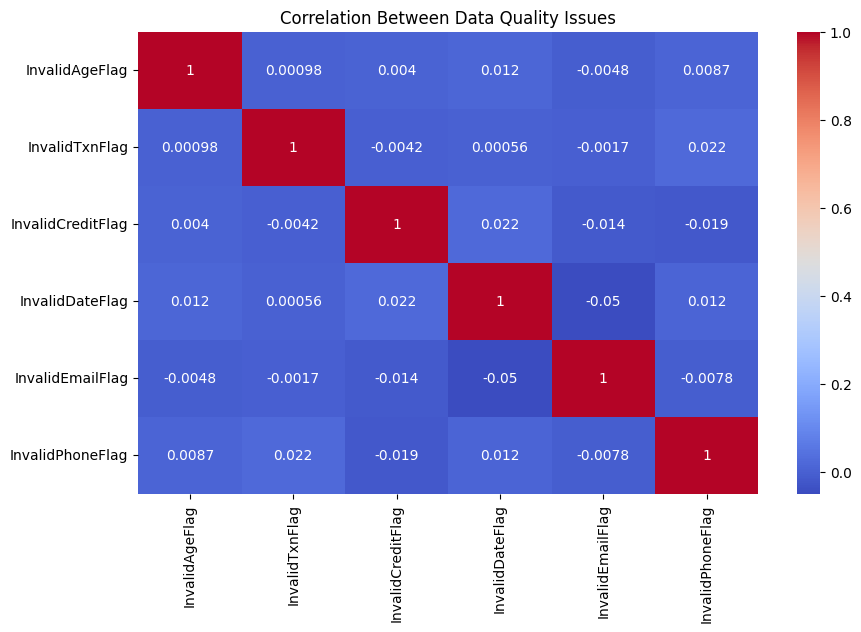

In [7]:
issue_cols = [
    'InvalidAgeFlag','InvalidTxnFlag','InvalidCreditFlag',
    'InvalidDateFlag','InvalidEmailFlag','InvalidPhoneFlag'
]

plt.figure(figsize=(10,6))
sns.heatmap(df[issue_cols].corr(), annot=True, cmap='coolwarm')

plt.title("Correlation Between Data Quality Issues")
plt.show()

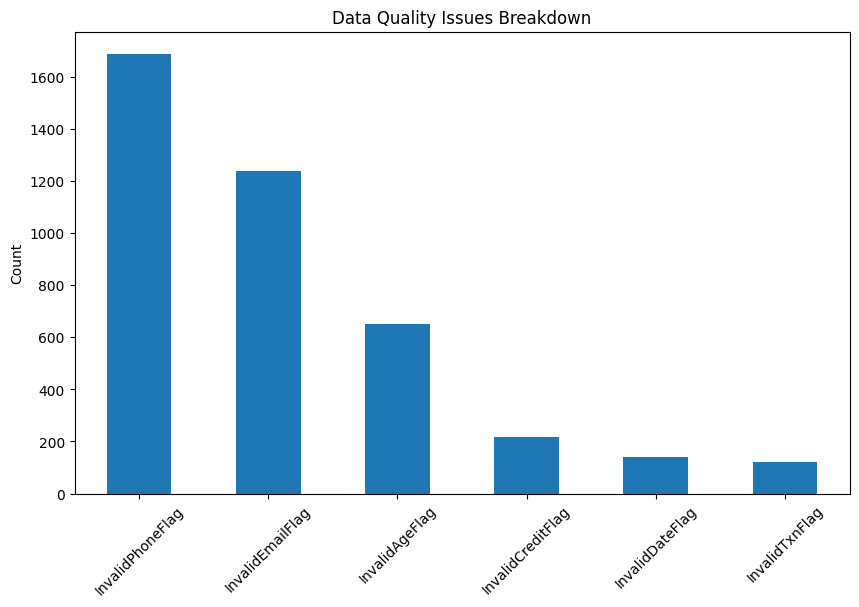

In [8]:
issue_counts = df[issue_cols].sum().sort_values(ascending=False)

plt.figure(figsize=(10,6))
issue_counts.plot(kind='bar')

plt.title("Data Quality Issues Breakdown")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.show()

In [9]:
# --- Clean Data Based on Rules ---

clean_df = df[
    (df['InvalidAgeFlag'] == 0) &
    (df['InvalidTxnFlag'] == 0) &
    (df['InvalidCreditFlag'] == 0) &
    (df['InvalidDateFlag'] == 0) &
    (df['InvalidEmailFlag'] == 0) &
    (df['InvalidPhoneFlag'] == 0)
]

# --- Data Quality Summary ---
total_records = len(df)
clean_records = len(clean_df)
bad_records = total_records - clean_records

print("Total Records:", total_records)
print("Clean Records:", clean_records)
print("Bad Records Removed:", bad_records)

# --- Save Outputs ---
clean_df.to_csv("clean_data.csv", index=False)

# Save rejected/bad records separately
bad_df = df[~df.index.isin(clean_df.index)]
bad_df.to_csv("rejected_data.csv", index=False)

# Save summary report
summary = pd.DataFrame({
    "Metric": ["Total Records", "Clean Records", "Rejected Records"],
    "Value": [total_records, clean_records, bad_records]
})

summary.to_csv("data_quality_summary.csv", index=False)

clean_df.head()

Total Records: 2500
Clean Records: 239
Bad Records Removed: 2261


,CustomerID,Age,Email,PhoneNumber,TransactionAmount,AccountBalance,TransactionType,Country,City,SignupDate,...,LoanStatus,ValidEmail,ValidPhone,InvalidAgeFlag,InvalidTxnFlag,InvalidCreditFlag,InvalidDateFlag,InvalidEmailFlag,InvalidPhoneFlag,DataQualityScore
15,10015,47,test@company.com,1234567890,3618.803936,46408.737824,Debit,India,NY,2020-05-09,...,Rejected,True,True,0,0,0,0,0,0,0
17,10017,36,test@company.com,1234567890,7165.018071,21279.861864,Debit,USA,Mumbai,2022-03-28,...,Approved,True,True,0,0,0,0,0,0,0
20,10020,56,test@company.com,1234567890,280.513393,5401.733243,Debit,India,Dallas,2023-10-10,...,Pending,True,True,0,0,0,0,0,0,0
27,10027,65,user@gmail.com,1234567890,3145.517759,41766.009558,Credit,India,NY,2021-12-23,...,Rejected,True,True,0,0,0,0,0,0,0
38,10038,28,test@company.com,1234567890,6727.553321,45552.156655,Credit,India,London,2020-02-19,...,Pending,True,True,0,0,0,0,0,0,0


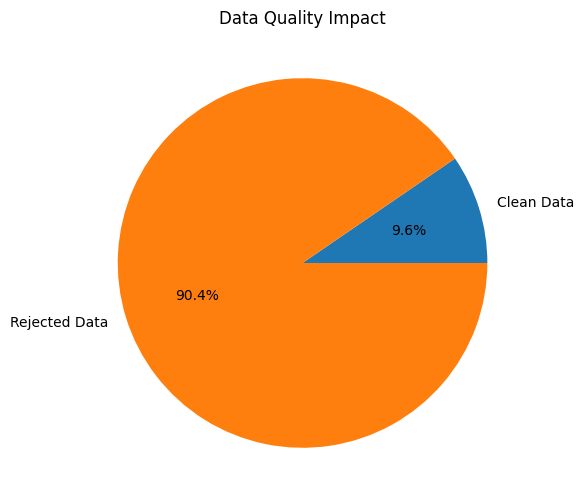

In [10]:
plt.figure(figsize=(6,6))

labels = ['Clean Data', 'Rejected Data']
values = [clean_records, bad_records]

plt.pie(values, labels=labels, autopct='%1.1f%%')

plt.title("Data Quality Impact")
plt.show()

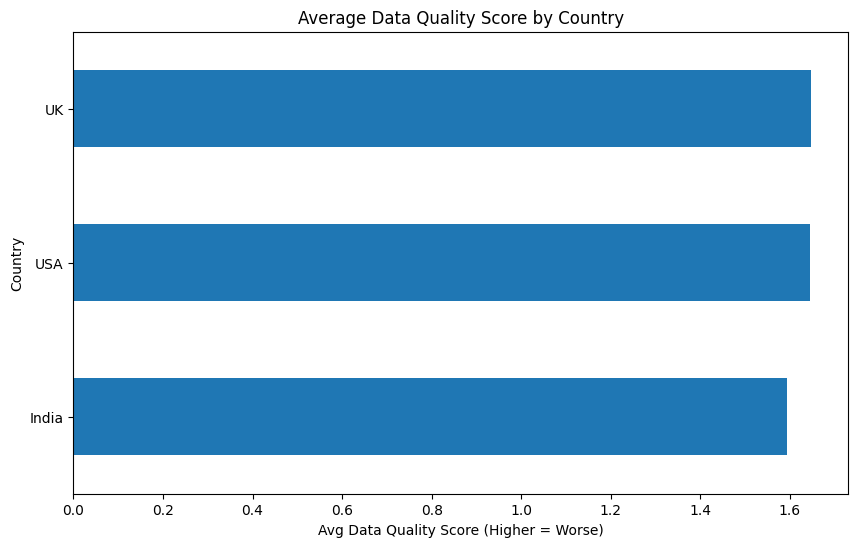

In [11]:
plt.figure(figsize=(10,6))

country_quality = df.groupby('Country')['DataQualityScore'].mean().sort_values()

country_quality.plot(kind='barh')

plt.title("Average Data Quality Score by Country")
plt.xlabel("Avg Data Quality Score (Higher = Worse)")
plt.ylabel("Country")

plt.show()

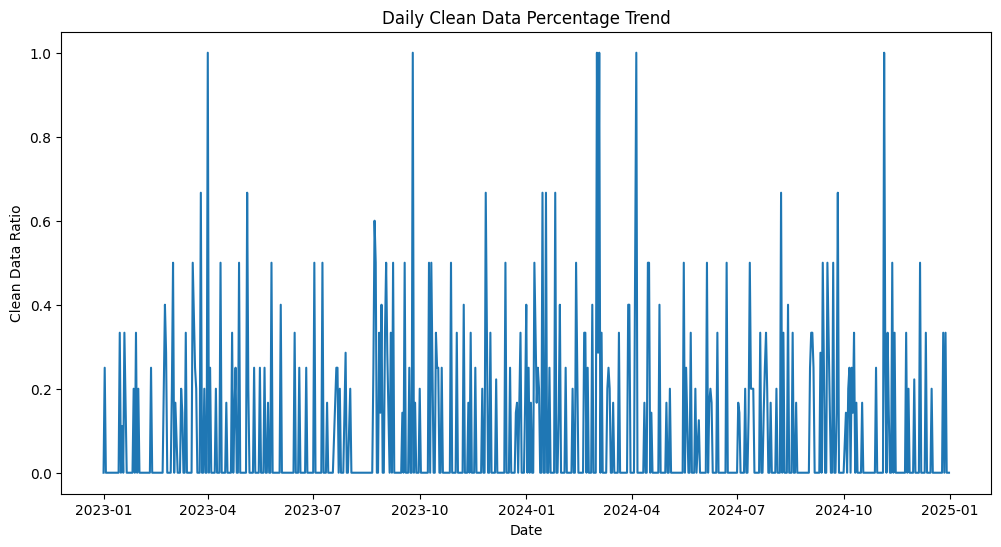

In [12]:
# Create flag
df['IsClean'] = np.where(df['DataQualityScore'] == 0, 1, 0)

# Group by date
daily_quality = df.groupby(df['TransactionDate'].dt.date)['IsClean'].mean()

plt.figure(figsize=(12,6))
plt.plot(daily_quality)

plt.title("Daily Clean Data Percentage Trend")
plt.xlabel("Date")
plt.ylabel("Clean Data Ratio")

plt.show()

In [13]:
worst_records = df.sort_values(by='DataQualityScore', ascending=False).head(10)

worst_records[['CustomerID','DataQualityScore','TransactionAmount','Email','PhoneNumber']]

,CustomerID,DataQualityScore,TransactionAmount,Email,PhoneNumber
2449,12449,6,-347.391580,None,None
1470,11470,5,3974.284895,None,invalid_phone
1393,11393,5,3767.266011,invalid_email,None
883,10883,5,-477.066500,None,invalid_phone
1985,11985,4,8905.825165,test@company.com,None
426,10426,4,-314.464530,invalid_email,None
2106,12106,4,2638.063482,None,None
946,10946,4,9134.807311,None,None
1704,11704,4,-278.893273,invalid_email,None
2396,12396,4,-431.483190,None,None


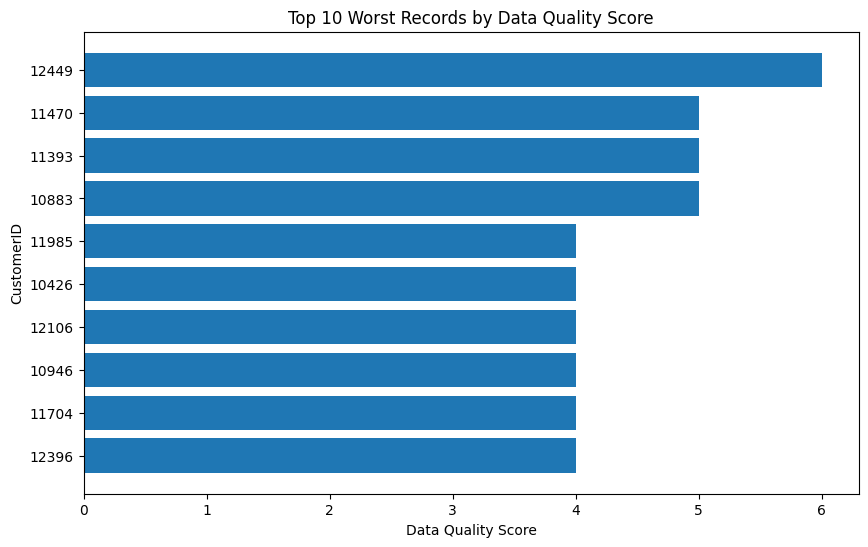

In [14]:
plt.figure(figsize=(10,6))

plt.barh(
    worst_records['CustomerID'].astype(str),
    worst_records['DataQualityScore']
)

plt.title("Top 10 Worst Records by Data Quality Score")
plt.xlabel("Data Quality Score")
plt.ylabel("CustomerID")

plt.gca().invert_yaxis()
plt.show()